# Data Mining Techniques

**Saman Zobeiry**


## Association Rule Evaluation — Kulczynski Measure

This section implements the **Kulczynski measure** for an association rule using a dataframe of frequent itemsets. The function receives the antecedent and consequent as `frozenset` objects, retrieves the support of each side and their union, and averages the two directional confidence values.


In [208]:
def kulczynski_measure(frequent_itemsets, antecedents, consequents):

    # create a dictionary to store supports
    support_dict = {}

    for index, row in frequent_itemsets.iterrows():
        support_dict[row["itemsets"]] = row["support"]

    # store antecedent and consequent
    antecedent = antecedents
    consequent = consequents

    # union of antecedent and consequent
    union_itemset = antecedent.union(consequent)

    # get support values
    support_antecedent = support_dict[antecedent]
    support_consequent = support_dict[consequent]
    support_union = support_dict[union_itemset]

    # compute confidence values
    confidence_A_to_B = support_union / support_antecedent
    confidence_B_to_A = support_union / support_consequent

    # kulczynski is the average of the two confidences
    kulczynski = (confidence_A_to_B + confidence_B_to_A) / 2

    return kulczynski
    

Association-rule mining is used to identify relationships between items that co-occur in transactional data. Support measures how frequently an item or itemset appears, and frequent itemsets provide the basis for constructing association rules.

For a rule A → B, confidence measures how often B appears when A appears. Because a one-directional confidence value can be influenced by highly frequent items, the Kulczynski measure evaluates the relationship in both directions.

The implementation below works directly from known frequent-itemset support values, locating the antecedent, consequent and union before computing the measure.


## Itemset Combinatorics

For a set of N items, the number of possible non-empty itemsets is:

**2^N - 1**


## IQR-Based Outlier Detection

The monthly rainfall values are analysed using the interquartile-range (IQR) rule. A value is treated as an outlier when it lies below Q1 - 1.5×IQR or above Q3 + 1.5×IQR.

For the supplied rainfall data, **5.49 mm** is identified as the outlier.


## Stock-Market Anomaly Detection with One-Class SVM

Daily percentage changes in the closing prices of **Microsoft (MSFT)**, **Ford (F)** and **Bank of America (BAC)** are standardised and analysed with an RBF **One-Class SVM**. The model labels each trading day as an inlier or outlier, followed by a 3D visualisation, a label-frequency histogram and calculation of the overall outlier rate.


In [209]:
stocks = pd.read_csv('stocks.csv')


In [ ]:
import os
os.getcwd()


In [ ]:
import os
os.listdir()



In [212]:
stocks.columns


Index(['Date', 'MSFT', 'F', 'BAC'], dtype='object')

In [213]:
stocks.head()
stocks.index


RangeIndex(start=0, stop=2518, step=1)

In [214]:
# Date is already the index; convert it to datetime
stocks.index = pd.to_datetime(stocks.index)

stocks.head()




,Date,MSFT,F,BAC
1970-01-01 00:00:00.000000000,1/3/2007,29.860001,7.51,53.330002
1970-01-01 00:00:00.000000001,1/4/2007,29.809999,7.70,53.669998
1970-01-01 00:00:00.000000002,1/5/2007,29.639999,7.62,53.240002
1970-01-01 00:00:00.000000003,1/8/2007,29.930000,7.73,53.450001
1970-01-01 00:00:00.000000004,1/9/2007,29.959999,7.79,53.500000


In [215]:
import numpy as np
import pandas as pd

# make sure values are numeric
stocks = stocks.apply(pd.to_numeric, errors='coerce')

# percentage change
percentage_change = 100 * (stocks.iloc[1:,:].values - stocks.iloc[:-1,:].values) / stocks.iloc[:-1,:].values
percentage_change = pd.DataFrame(percentage_change, index=stocks.index[1:], columns=stocks.columns)

percentage_change.head()


,Date,MSFT,F,BAC
1970-01-01 00:00:00.000000001,NaN,-0.167455,2.529960,0.637532
1970-01-01 00:00:00.000000002,NaN,-0.570278,-1.038961,-0.801185
1970-01-01 00:00:00.000000003,NaN,0.978411,1.443570,0.394438
1970-01-01 00:00:00.000000004,NaN,0.100231,0.776197,0.093543
1970-01-01 00:00:00.000000005,NaN,-1.001332,-0.770218,0.149536


In [216]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

# Use the percentage changes as the input features
X = percentage_change[['MSFT', 'F', 'BAC']].values

# Scale features (important for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train one-class SVM model (1 = inlier, -1 = outlier)
one_class_svm_model = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
predicted_labels = one_class_svm_model.fit_predict(X_scaled)

# Store the labels in a DataFrame (keep Date index)
label_results = pd.DataFrame(predicted_labels, index=percentage_change.index, columns=['Label'])

label_results.head()


,Label
1970-01-01 00:00:00.000000001,1
1970-01-01 00:00:00.000000002,1
1970-01-01 00:00:00.000000003,1
1970-01-01 00:00:00.000000004,1
1970-01-01 00:00:00.000000005,1


In [217]:
label_results['Label'].value_counts()


Label
 1    2390
-1     127
Name: count, dtype: int64

In [218]:
counts = label_results['Label'].value_counts()
outlier_pct = 100 * counts[-1] / counts.sum()
outlier_pct


np.float64(5.045689312673818)

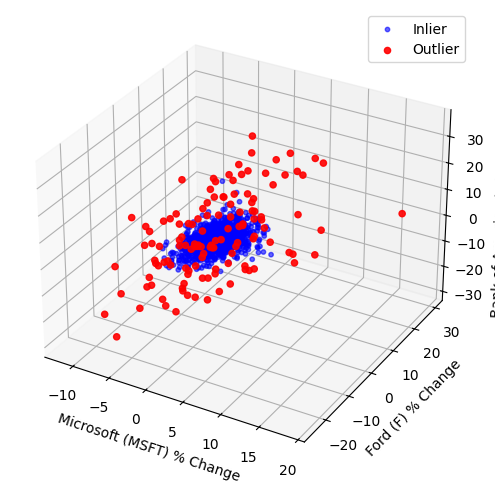

In [219]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Separate inliers and outliers using the predicted labels
inlier_mask = (label_results['Label'] == 1)
outlier_mask = (label_results['Label'] == -1)

inliers = percentage_change[inlier_mask]
outliers = percentage_change[outlier_mask]

# 3D scatterplot
figure = plt.figure(figsize=(10, 6))
axis = figure.add_subplot(111, projection='3d')

axis.scatter(inliers['MSFT'], inliers['F'], inliers['BAC'],
             c='blue', label='Inlier', alpha=0.6, s=10)

axis.scatter(outliers['MSFT'], outliers['F'], outliers['BAC'],
             c='red', label='Outlier', alpha=0.9, s=20)


axis.set_xlabel('Microsoft (MSFT) % Change')
axis.set_ylabel('Ford (F) % Change')
axis.set_zlabel('Bank of America (BAC) % Change')
axis.legend()

plt.show()


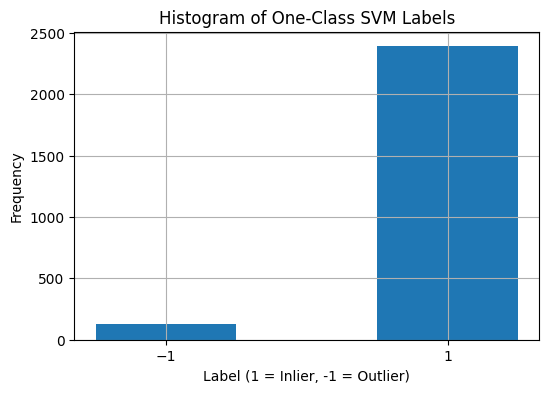

In [220]:
plt.figure(figsize=(6,4))
label_results['Label'].hist(bins=[-1.5, -0.5, 0.5, 1.5])
plt.xticks([-1, 1])
plt.xlabel('Label (1 = Inlier, -1 = Outlier)')
plt.ylabel('Frequency')
plt.title('Histogram of One-Class SVM Labels')
plt.show()



In [221]:
# calculate outlier percentage
counts = label_results['Label'].value_counts()

total_days = counts.sum()
outlier_days = counts[-1]

outlier_percentage = (outlier_days / total_days) * 100
outlier_percentage


np.float64(5.045689312673818)

The stock-price analysis uses percentage changes rather than raw closing prices so that movements across the three stocks are comparable.

Mahalanobis distance is a parametric approach that measures distance from the multivariate centre while accounting for covariance. A k-nearest-neighbour method instead uses local proximity. The One-Class SVM learns a boundary around the region containing typical observations and identifies points outside that learned region as anomalies.

Using the percentage changes for MSFT, F and BAC, the One-Class SVM classified **2,390 observations as inliers** and **127 as outliers**, corresponding to approximately **5.05%** of the observations.


## PCA and k-Nearest-Neighbour Outlier Scoring

The housing dataset is reduced to **two principal components** with PCA. A **k-nearest-neighbour** proximity score with k=2 is then calculated in the reduced space. Larger second-neighbour distances indicate more isolated observations and therefore stronger outlier candidates.


In [222]:

from pandas import read_csv

# Loading the dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.csv'
df = read_csv(url, header=None)

# Extracting the values from the dataframe
data = df.values

# Split dataset into input and output elements
X, y = data[:, :-1], data[:, -1]

# Summarize the shape of the dataset
print(X.shape, y.shape)


(506, 13) (506,)


In [223]:
from sklearn.decomposition import PCA

# Apply PCA with 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

#  shape of the transformed data
print(X_pca.shape)


(506, 2)


In [224]:
from sklearn.neighbors import NearestNeighbors

# k-nearest neighbours with k = 2
knn = NearestNeighbors(n_neighbors=2)
knn.fit(X_pca)

distances, indices = knn.kneighbors(X_pca)

# Outlier score is distance to the 2nd nearest neighbour
outlier_score = distances[:, 1]



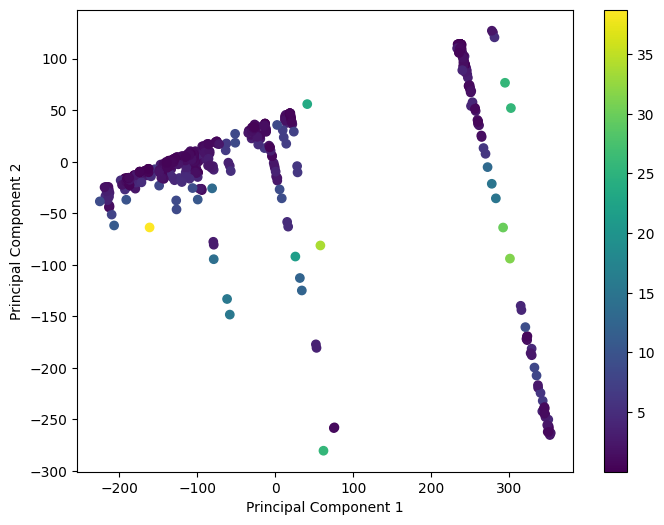

In [225]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=outlier_score)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar()
plt.show()


Principal Component Analysis reduces the numerical housing features to two dimensions while preserving the dominant directions of variation.

After the PCA transformation, a proximity-based outlier score is calculated from the distance to each observation's second-nearest neighbour. The final scatterplot uses the two principal components as coordinates and colours each observation by its outlier score.


## Web Table Extraction with BeautifulSoup

A small HTML table containing income and shopping-habit data is parsed with **BeautifulSoup**, cleaned, and converted into a pandas DataFrame.


In [226]:
import pandas as pd
from bs4 import BeautifulSoup
from urllib.request import urlopen


In [227]:
url = "http://eecs.qmul.ac.uk/~emmanouilb/income_table.html"


In [ ]:
try:
    html = urlopen(url)
    soup = BeautifulSoup(html, "lxml")
except:
    with open("income_table.html", "r", encoding="utf-8") as f:
        soup = BeautifulSoup(f, "lxml")


In [ ]:
rows = soup.find_all("tr")
len(rows)


NameError: name 'soup' is not defined

In [ ]:
header_list = []

for th in rows[0].find_all("th"):
    header_list.append(th.get_text().strip())

header_list


NameError: name 'rows' is not defined

In [ ]:
table_list = []

for row in rows[1:]:
    row_data = []
    for td in row.find_all("td"):
        row_data.append(td.get_text().strip())
    if len(row_data) > 0:
        table_list.append(row_data)

len(table_list)


NameError: name 'rows' is not defined

In [ ]:
df = pd.DataFrame(table_list, columns=header_list)
df.head()


""


In [ ]:
import os
os.getcwd()


In [ ]:
import os
os.listdir()


In [ ]:
os.listdir()


In [ ]:
import pandas as pd
from bs4 import BeautifulSoup

# HTML content used due to DNS failure accessing QMUL server
html = """
<table border="1">
<tr>
    <th>Income</th>
    <th>Online Shopping</th>
    <th>In-store Shopping</th>
</tr>
<tr>
    <td>Low</td>
    <td>5</td>
    <td>15</td>
</tr>
<tr>
    <td>Medium</td>
    <td>12</td>
    <td>18</td>
</tr>
<tr>
    <td>High</td>
    <td>20</td>
    <td>10</td>
</tr>
</table>
"""

soup = BeautifulSoup(html, "lxml")

table = soup.find("table")
rows = table.find_all("tr")

# FIXED LINE (this is what was broken)
headers = [c.get_text(strip=True) for c in rows[0].find_all(["th", "td"])]

data = []
for r in rows[1:]:
    cells = [c.get_text(strip=True) for c in r.find_all(["th", "td"])]
    data.append(cells)

df = pd.DataFrame(data, columns=headers)

print(df.shape)
df


(3, 3)


,Income,Online Shopping,In-store Shopping
0,Low,5,15
1,Medium,12,18
2,High,20,10


The web-data workflow uses `urllib`, BeautifulSoup and pandas. The original source endpoint was unavailable during execution because of a DNS-resolution failure, so the same table structure was parsed from local HTML instead.

BeautifulSoup extracts the table rows, header cells and data cells. Whitespace is removed during cleaning, and the extracted values are converted into a pandas DataFrame.


## Document Clustering with TF-IDF and K-Means

Eleven Wikipedia articles covering machine learning, statistics and data-management topics are collected and converted into **TF-IDF** vectors. **K-Means** is then applied to the document vectors, with the elbow method used to select an appropriate number of clusters.


In [ ]:
!pip install wikipedia
!pip install statsmodels --upgrade

import pandas as pd
import wikipedia
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans


  Using cached wikipedia-1.4.0.tar.gz (27 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11757 sha256=78be14061fee303415b35bc3a25c04f1959a49726309613ab0393a64bb7b5286
  Stored in directory: /Users/samanzobeiry/Library/Caches/pip/wheels/79/1d/c8/b64e19423cc5a2a339450ea5d145e7c8eb3d4aa2b150cde33b
Successfully built wikipedia

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 8.7 MB/s eta 0:00:00 0:00:01
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [229]:
articles = [
    'Supervised learning',
    'Unsupervised learning',
    'Semi-supervised learning',
    'Association rule learning',
    'Anomaly detection',
    'Cluster analysis',
    'Dimensionality reduction',
    'Regression analysis',
    'Statistical classification',
    'Data warehouse',
    'Online analytical processing'
]

wiki_text = []
titles = []

for a in articles:
    print('loading:', a)
    page = wikipedia.page(a, auto_suggest=False)
    wiki_text.append(page.content)
    titles.append(a)

print(wiki_text[0])


loading: Supervised learning
loading: Unsupervised learning
loading: Semi-supervised learning
loading: Association rule learning
loading: Anomaly detection
loading: Cluster analysis
loading: Dimensionality reduction
loading: Regression analysis
loading: Statistical classification
loading: Data warehouse
loading: Online analytical processing
In machine learning, supervised learning (SL) is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs. This process involves training a statistical model using labeled data, meaning each piece of input data is provided with the correct output. For instance, if you want a model to identify cats in images, supervised learning would involve feeding it many images of cats (inputs) that are explicitly labeled "cat" (outputs).
The goal of supervised learning is for the trained model to accurately predict the output for new, unseen data. This requires the algorithm to effec

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(wiki_text)

print(X.shape)


(11, 4167)


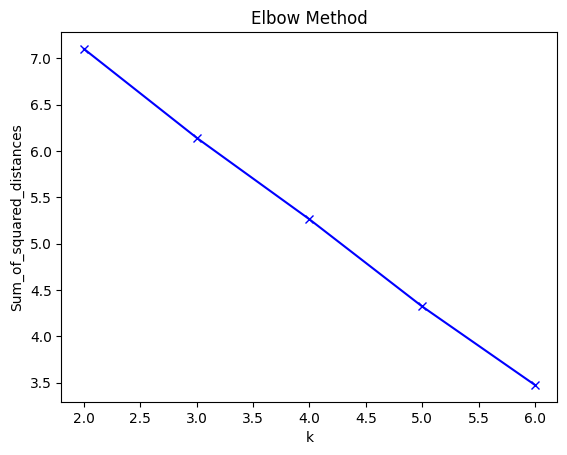

In [ ]:
Sum_of_squared_distances = []
K = range(2, 7)

for k in K:
    km = KMeans(n_clusters=k, max_iter=200, n_init=10)
    km.fit(X)
    Sum_of_squared_distances.append(km.inertia_)

plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method')
plt.show()


In [ ]:
true_k = 3   # number of clusters chosen from the elbow plot

# create k-means model
model = KMeans(n_clusters=true_k, init='k-means++', max_iter=200, n_init=10)

# fit model to tf-idf data
model.fit(X)

# get cluster labels
labels = model.labels_

# put document titles and cluster labels into a table
wiki_clusters = pd.DataFrame(
    list(zip(titles, labels)),
    columns=['title', 'cluster']
)

print(wiki_clusters.sort_values(by='cluster'))
print()


print("Clustering Results (k=%d):" % true_k)
print("=" * 45)

for c in sorted(wiki_clusters['cluster'].unique()):
    print("\nCluster %d:" % c)
    for t in wiki_clusters[wiki_clusters['cluster'] == c]['title']:
        print(" -", t.lower())


                           title  cluster
0            Supervised learning        0
2       Semi-supervised learning        0
3      Association rule learning        0
7            Regression analysis        0
10  Online analytical processing        1
9                 Data warehouse        1
1          Unsupervised learning        2
4              Anomaly detection        2
6       Dimensionality reduction        2
5               Cluster analysis        2
8     Statistical classification        2

Clustering Results (k=3):

Cluster 0:
 - supervised learning
 - semi-supervised learning
 - association rule learning
 - regression analysis

Cluster 1:
 - data warehouse
 - online analytical processing

Cluster 2:
 - unsupervised learning
 - anomaly detection
 - cluster analysis
 - dimensionality reduction
 - statistical classification


The document-clustering pipeline represents each Wikipedia article with TF-IDF features and applies K-Means to the resulting document-term matrix.

The elbow curve shows a clear reduction in within-cluster distance up to approximately **k = 3**, after which the improvement becomes smaller, so three clusters are used for the final model.

The resulting groups separate related terminology across learning methods, statistical/data-analysis topics and data-management concepts.
